In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf

from sklearn.model_selection import train_test_split

pd.options.display.max_columns = None

In [2]:
df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/room_cleaning_evaluation.csv')

In [3]:
p = ['bedboard', 'bedcontroller', 'bedrail', 'bedside_table', 'doorhandle', \
     'handrail', 'overhead_table', 'tap' , 'toiletseat', 'UBhandrail', \
     'toilet_seat_switch', 'callbotton', 'chair', 'dispencer', 'closette', \
     'showerhead', 'UBlight_sw']

# reduction列の欠損値をpart別の平均値で埋める
for part in p:
    mask = df['part'] == part
    mean_val = df.loc[mask, 'reduction'].mean()
    df.loc[mask, 'reduction'] = df.loc[mask, 'reduction'].fillna(mean_val)

# score列の欠損値をpart別の平均値で埋める
for part in p:
    mask = df['part'] == part
    mean_val = df.loc[mask, 'score'].mean()
    df.loc[mask, 'score'] = df.loc[mask, 'score'].fillna(mean_val)

dfx = df[['reduction']]

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
temp = sc.fit_transform(dfx)
temp

array([[-0.02043465],
       [ 0.18112894],
       [ 0.28177636],
       ...,
       [ 0.15729153],
       [ 0.25906686],
       [ 0.29400455]])

In [5]:
df['reduction'] = temp[:,0]

In [6]:
Y = np.array(df['outcome'])
X = np.array(df[['score', 'reduction']])

In [7]:
print("Y=", Y.shape, ", X=", X.shape)

Y= (1697,) , X= (1697, 2)


In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, random_state=0)

In [9]:
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (830,) , X_train= (830, 2)
Y_valid= (357,) , X_valid= (357, 2)
Y_test= (510,) , X_test= (510, 2)


In [10]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Dense(8, activation='relu', input_shape=(2,)))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(optimizer = "rmsprop", loss='binary_crossentropy', metrics=['accuracy'])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
%%time
# 学習の実施
log = model.fit(X_train, Y_train, epochs=5000, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                            min_delta=0, patience=100,
                                                            verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8614 - loss: 0.6793 - val_accuracy: 0.8711 - val_loss: 0.6456
Epoch 2/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8853 - loss: 0.6301 - val_accuracy: 0.8711 - val_loss: 0.5895
Epoch 3/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - accuracy: 0.8758 - loss: 0.5791 - val_accuracy: 0.8711 - val_loss: 0.5428
Epoch 4/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - accuracy: 0.8951 - loss: 0.5249 - val_accuracy: 0.8711 - val_loss: 0.5028
Epoch 5/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.8790 - loss: 0.4934 - val_accuracy: 0.8711 - val_loss: 0.4665
Epoch 6/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.8895 - loss: 0.4477 - val_accuracy: 0.8711 - val_loss: 0.4371
Epoch 7/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.8807 - loss: 0.4238 - val_accuracy: 0.8711 - val_loss: 0.4129
Epoch 8/5000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - accuracy: 0.8833 - loss: 0.3942 - va

Text(0, 0.5, 'crossentropy')

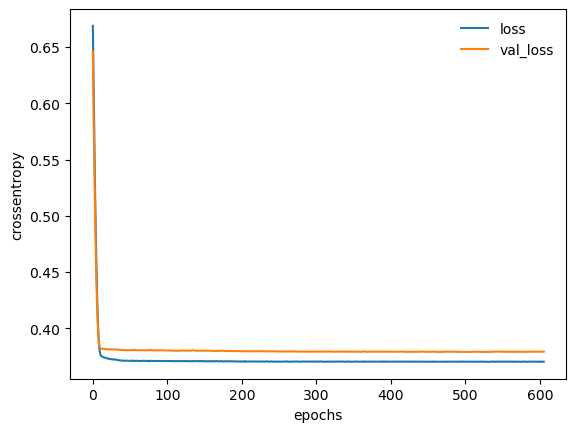

In [13]:
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [14]:
Y_pred = model.predict(X_test)
Y_pred_cls = (Y_pred > 0.5).astype("int32")
Y_pred_ = Y_pred_cls.reshape(-1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [15]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred_))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       442
           1       0.00      0.00      0.00        68

    accuracy                           0.87       510
   macro avg       0.43      0.50      0.46       510
weighted avg       0.75      0.87      0.80       510



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
